# Sea Ice Concentration Calculation
author: Dahlia Dry

w/assistance from GitHub Copilot

In [24]:
import xarray as xr
import numpy as np
from pathlib import Path
import pandas as pd
import plotly.graph_objects as go
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

In [ ]:
SCAN_POSITIONS = 13
WINDOW = 7   # 15-day smoothing

# Brightness-temperature filtering thresholds (from Table 1)
TB_MIN_ICE  = 100
TB_MAX_ICE  = 274
TB_MIN_WATER =  90
TB_MAX_WATER = 180

# Gradient Ratio ice classification threshold
GR_THRESHOLD = -0.015   # MYI if GR < threshold, FYI otherwise

## Tie Point Calculation

In [3]:
# Output storage structure:
# tiepoints[category][channel][scan_pos]
categories = ["water", "FYI", "MYI"]
tie_raw  = {cat: {ch: {scan: [] for scan in range(SCAN_POSITIONS)} for ch in ["ch1", "ch2"]} for cat in categories}
tie_smth = {cat: {ch: {scan: [] for scan in range(SCAN_POSITIONS)} for ch in ["ch1", "ch2"]} for cat in categories}

In [ ]:
for day in range(1,32):
    print(f"Processing march1976_daily/march1976_197603{day:02d}.nc")
    day_ds = xr.open_dataset(f"../preprocessed-data/march1976_daily/march1976_197603{day:02d}.nc")

    # calculate gradient ratio
    GR = (day_ds.TBCH1 - day_ds.TBCH2) / (day_ds.TBCH1 + day_ds.TBCH2)

    #-------------------------------------------------------------
    # SELECT PURE WATER + ICE PIXELS USING ERA5 SIC & TB THRESHOLDS
    #-------------------------------------------------------------
    # Land mask
    ocean_mask = day_ds.lsm == 0

    # Water = ERA5 SIC = 0 + TB limits
    mask_water = (
        (day_ds.siconc == 0) &
        (day_ds.TBCH1 > TB_MIN_WATER) & (day_ds.TBCH1 < TB_MAX_WATER) &
        (day_ds.TBCH2 > TB_MIN_WATER) & (day_ds.TBCH2 < TB_MAX_WATER) &
        ocean_mask
    )

    # Ice = ERA5 SIC > 0.8 + TB limits
    mask_ice = (
        (day_ds.siconc > 0.8) &
        (day_ds.TBCH1 > TB_MIN_ICE) & (day_ds.TBCH1 < TB_MAX_ICE) &
        (day_ds.TBCH2 > TB_MIN_ICE) & (day_ds.TBCH2 < TB_MAX_ICE) &
        ocean_mask
    )

    # Split into FYI / MYI using gradient ratio
    mask_MYI = mask_ice & (GR < GR_THRESHOLD)
    mask_FYI = mask_ice & (GR >= GR_THRESHOLD)
    #-------------------------------------------------------------
    # COMPUTE DAILY MEAN TIEPOINTS PER SCAN POSITION
    # -------------------------------------------------------------
    for scan in range(SCAN_POSITIONS):
        print(f"  Scan position {scan+1}/{SCAN_POSITIONS}")
        # For each category and channel
        for cat, mask in zip(["water", "FYI", "MYI"],
                             [mask_water, mask_FYI, mask_MYI]):
            # Extract scan slice
            sub = day_ds.where(mask,drop=True).isel(n13_obs=scan)
            #print(sub)
            for ch_name, ch_data in zip(["ch1", "ch2"],
                                        [sub.TBCH1, sub.TBCH2]):
                vals = ch_data
                if vals.size == 0:
                    tie_raw[cat][ch_name][scan].append(np.nan)
                else:
                    tie_raw[cat][ch_name][scan].append(float(vals.mean()))

Processing march1976_daily/march1976_19760301.nc
  Scan position 1/13
<xarray.Dataset> Size: 1MB
Dimensions:  (time: 2363, obs: 13)
Coordinates:
  * time     (time) datetime64[ns] 19kB 1975-12-31 ... 1978-08-04T17:06:00
Dimensions without coordinates: obs
Data variables:
    LAT      (time, obs) float64 246kB nan nan nan nan nan ... nan nan nan nan
    LON      (time, obs) float64 246kB nan nan nan nan nan ... nan nan nan nan
    TBCH1    (time, obs) float64 246kB nan nan nan nan nan ... nan nan nan nan
    TBCH2    (time, obs) float64 246kB nan nan nan nan nan ... nan nan nan nan
    lsm      (time, obs) float64 246kB nan nan nan nan nan ... nan nan nan nan
    siconc   (time, obs) float64 246kB nan nan nan nan nan ... nan nan nan nan
Attributes:
    source_files:  Nimbus6-SCAMS_1976m0301t002856_o03527_DS17_era5.nc, Nimbus...
    created_by:    seaice_calculation.py
<xarray.Dataset> Size: 478kB
Dimensions:  (time: 757, obs: 13)
Coordinates:
  * time     (time) datetime64[ns] 6kB 1976-

In [ ]:
def plot_tiepoints(day):
    day_ds = xr.open_dataset(f"../preprocessed-data/march1976_daily/march1976_197603{day:02d}.nc")
    GR = (day_ds.TBCH1 - day_ds.TBCH2) / (day_ds.TBCH1 + day_ds.TBCH2)
    fig = go.Figure([
        go.Scatter(x=day_ds.TBCH2.values.flatten(), 
                   y=day_ds.TBCH1.values.flatten(), 
                   mode='markers', name='OBS',
                   marker=dict(
                       color=GR.values.flatten(),                 # numeric array used for coloring
                       colorscale='Viridis',     # or 'Turbo', 'Plasma', ...
                       colorbar=dict(title='Gradient Ratio'), 
                       showscale=True,
                       size=7,
                       #symbol='square'
                   )),
        go.Scatter(x=[tie_raw['FYI']['ch2'][s][day-1] for s in range(SCAN_POSITIONS)], 
                   y=[tie_raw['FYI']['ch1'][s][day-1] for s in range(SCAN_POSITIONS)], 
                   mode='markers', name='FYI',
                marker=dict(color='cyan', size=8)),
        go.Scatter(x=[tie_raw['MYI']['ch2'][s][day-1] for s in range(SCAN_POSITIONS)], 
                   y=[tie_raw['MYI']['ch1'][s][day-1] for s in range(SCAN_POSITIONS)], 
                   mode='markers', name='MYI',
                marker=dict(color='magenta', size=8)),
        go.Scatter(x=[tie_raw['water']['ch2'][s][day-1] for s in range(SCAN_POSITIONS)], 
                   y=[tie_raw['water']['ch1'][s][day-1] for s in range(SCAN_POSITIONS)], 
                   mode='markers', name='OW',
                marker=dict(color='orange', size=8))
    ])

    fig.update_layout(title='Tie points', xaxis_title='TB 31.65 GHz', yaxis_title='TB 22.35 GHz',
                    legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='right', x=1))

    fig.show()

def plot_geo(ds):
    # Extract variables from the dataset
    lat = ds.LAT
    lon = ds.LON
    tbch1 = ds.TBCH1

    # Create the map with geographic projection
    plt.figure(figsize=(12, 8))
    ax = plt.axes(projection=ccrs.PlateCarree())

    # Add coastlines and continents
    ax.coastlines()
    ax.add_feature(cfeature.LAND, facecolor='lightgray')
    ax.add_feature(cfeature.OCEAN, facecolor='white')
    ax.gridlines(draw_labels=True)

    # Plot the TBCH1 data
    scatter = ax.scatter(lon, lat, c=tbch1, cmap='viridis', s=10, transform=ccrs.PlateCarree())
    plt.colorbar(scatter, label='TBCH1 (K)')
    plt.title('TBCH1 Temperature Map')
    plt.tight_layout()
    plt.show()

In [23]:
plot_tiepoints(20)

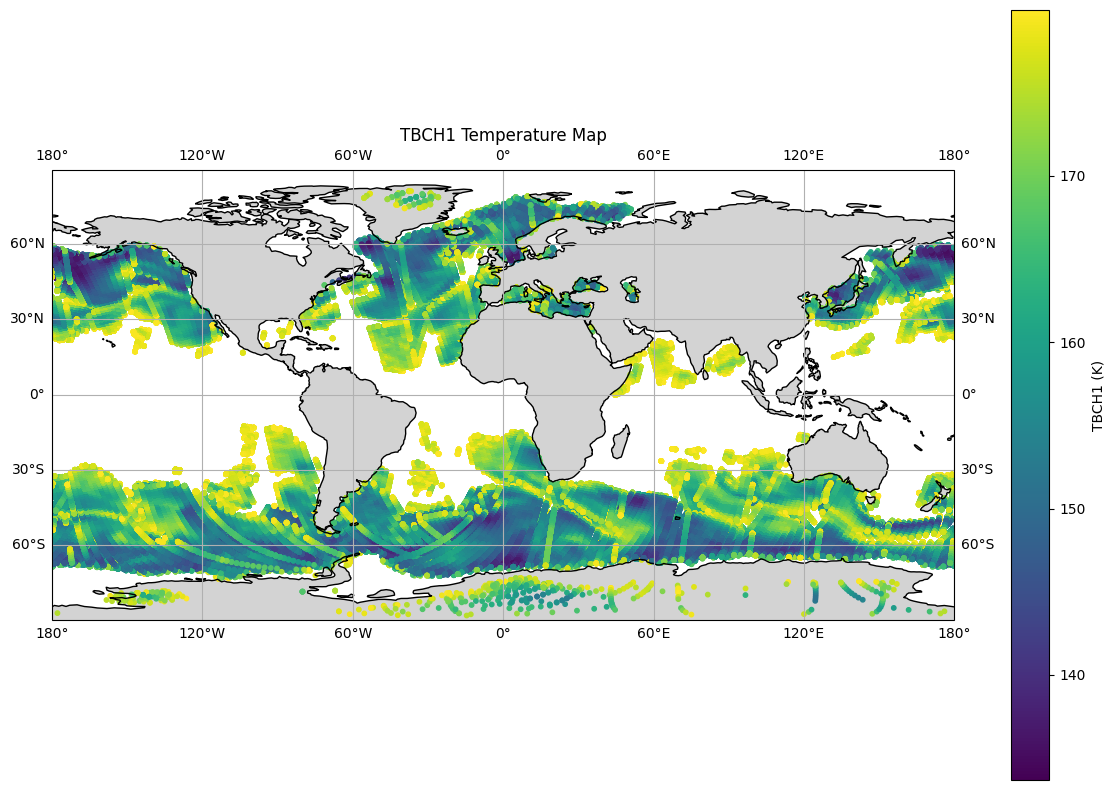

In [ ]:
day_ds = xr.open_dataset(f"../preprocessed-data/march1976_daily/march1976_19760320.nc")
# Land mask
ocean_mask = day_ds.lsm == 0

# Water = ERA5 SIC = 0 + TB limits
mask_water = (
    (day_ds.siconc == 0) &
    (day_ds.TBCH1 > TB_MIN_WATER) & (day_ds.TBCH1 < TB_MAX_WATER) &
    (day_ds.TBCH2 > TB_MIN_WATER) & (day_ds.TBCH2 < TB_MAX_WATER) &
    ocean_mask
)

new_ds = day_ds.where(mask_water, drop=True)
plot_geo(new_ds)